In [1]:
!pip install tensorflow opencv-python scikit-learn pandas numpy matplotlib tqdm

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (6).zip to archive (6) (1).zip


In [4]:
zip_file = "archive (6).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [5]:
os.listdir("dataset")

['socal2_cleaned_mod.csv', 'socal_pics']

In [6]:
csv_path = "dataset/socal2_cleaned_mod.csv"

df = pd.read_csv(csv_path)

df.head()

,image_id,n_citi,bed,bath,sqft,price
0,1,48,3,2,713,228500
1,4,55,4,3,2547,385100
2,6,55,4,3,2769,415000
3,7,48,5,2,2600,545000
4,8,48,5,2,2600,545000


In [7]:
print(df.shape)

df.info()

df.describe()

(12518, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12518 entries, 0 to 12517
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  12518 non-null  int64
 1   n_citi    12518 non-null  int64
 2   bed       12518 non-null  int64
 3   bath      12518 non-null  int64
 4   sqft      12518 non-null  int64
 5   price     12518 non-null  int64
dtypes: int64(6)
memory usage: 586.9 KB


,image_id,n_citi,bed,bath,sqft,price
count,12518.000000,12518.000000,12518.000000,12518.000000,12518.000000,1.251800e+04
mean,7671.242131,216.511104,3.549369,2.423390,2177.679981,6.853688e+05
std,4525.326949,113.610683,1.019620,0.955929,1024.045854,3.652546e+05
min,1.000000,0.000000,1.000000,0.000000,352.000000,1.950000e+05
25%,3717.250000,118.000000,3.000000,2.000000,1431.000000,4.350000e+05
50%,7718.500000,225.000000,3.000000,2.000000,1949.000000,6.199000e+05
75%,11572.250000,313.000000,4.000000,3.000000,2744.750000,7.999000e+05
max,15472.000000,414.000000,12.000000,36.000000,17667.000000,2.000000e+06


In [8]:
df.isnull().sum()

,0
image_id,0
n_citi,0
bed,0
bath,0
sqft,0
price,0


In [9]:
df = df.dropna()

In [10]:
encoder = LabelEncoder()

df["n_citi"] = encoder.fit_transform(df["n_citi"])

In [11]:
image_folder = "dataset/socal_pics/train/house"

df["image_path"] = df["image_id"].astype(str) + ".jpg"

df["image_path"] = df["image_path"].apply(
    lambda x: os.path.join(image_folder, x)
)

In [12]:
exists = []

for path in df["image_path"]:
    exists.append(os.path.exists(path))

df["exists"] = exists

print(df["exists"].value_counts())

exists
False    10518
True      2000
Name: count, dtype: int64


In [13]:
df = df[df["exists"] == True]

df.reset_index(drop=True, inplace=True)

print(df.shape)

(2000, 8)


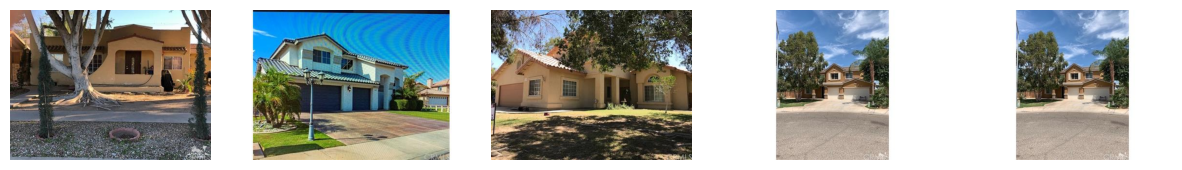

In [14]:
plt.figure(figsize=(15,6))

for i in range(5):

    image = cv2.imread(df.loc[i,"image_path"])

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)

    plt.imshow(image)

    plt.axis("off")

plt.show()

In [15]:
tabular_features = df[[
    "bed",
    "bath",
    "sqft",
    "n_citi"
]]

target = df["price"]

In [16]:
scaler = StandardScaler()

tabular_features = scaler.fit_transform(tabular_features)

print(tabular_features.shape)

(2000, 4)


In [17]:
cnn = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

print("ResNet50 Loaded Successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Loaded Successfully!


In [18]:
def preprocess_image(path):

    image = cv2.imread(path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image = cv2.resize(image, (224,224))

    image = img_to_array(image)

    image = preprocess_input(image)

    return image

In [19]:
image_features = []

print("Extracting Image Features...")

for path in tqdm(df["image_path"]):

    image = preprocess_image(path)

    image = np.expand_dims(image, axis=0)

    feature = cnn.predict(image, verbose=0)

    image_features.append(feature.flatten())

print("Feature Extraction Completed!")

Extracting Image Features...


100%|██████████| 2000/2000 [11:55<00:00,  2.80it/s]

Feature Extraction Completed!


In [20]:
image_features = np.array(image_features)

print(image_features.shape)

(2000, 2048)


In [21]:
print(image_features[0])

[0.0966718  0.4444213  0.45128748 ... 0.46997517 0.08631531 0.00784035]


In [22]:
print(tabular_features.shape)

(2000, 4)


In [23]:
combined_features = np.concatenate(
    [image_features, tabular_features],
    axis=1
)

print(combined_features.shape)

(2000, 2052)


In [24]:
y = target.values

print(y.shape)

(2000,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    combined_features,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (1600, 2052)
Testing Samples  : (400, 2052)


In [26]:
feature_scaler = StandardScaler()

X_train = feature_scaler.fit_transform(X_train)

X_test = feature_scaler.transform(X_test)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 2052)
(400, 2052)
(1600,)
(400,)


In [28]:
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)

np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Features Saved Successfully!")

Features Saved Successfully!


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
model = Sequential()

model.add(Dense(1024, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     2,102,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,791,425 (10.65 MB)

 Trainable params: 2,791,425 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [32]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - loss: 428888326144.0000 - mae: 531927.4375 - val_loss: 283501232128.0000 - val_mae: 411832.9375
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 186242809856.0000 - mae: 307662.9375 - val_loss: 126219190272.0000 - val_mae: 237728.0000
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 107244797952.0000 - mae: 231313.2812 - val_loss: 101652848640.0000 - val_mae: 227681.4219
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 74378534912.0000 - mae: 193666.6562 - val_loss: 91746140160.0000 - val_mae: 208853.5312
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 56433258496.0000 - mae: 167928.9531 - val_loss: 86472228864.0000 - val_mae: 196118.5781
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 44128104448.0000 - mae: 147485.8906 - val_loss: 81738448896.0000 - val_mae: 196979.9688
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 32082810880.0000 - mae: 126404.7031 - val_loss: 7923

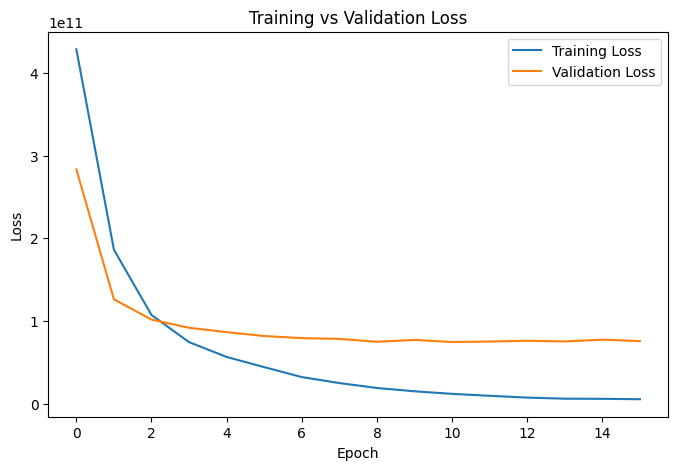

In [34]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

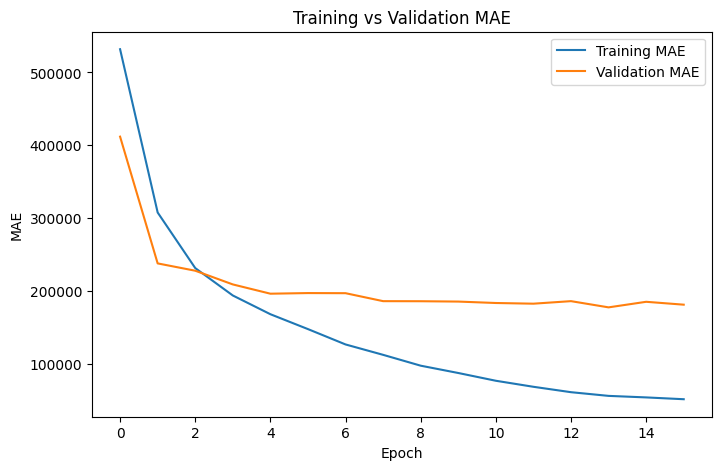

In [35]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

In [36]:
model.save("HousePricePredictionModel.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [37]:
import os

print(os.listdir())

['.config', 'y_test.npy', 'X_test.npy', 'archive (6) (1).zip', 'X_train.npy', 'dataset', 'HousePricePredictionModel.keras', '.ipynb_checkpoints', 'archive (6).zip', 'y_train.npy', 'sample_data']


In [38]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np
import matplotlib.pyplot as plt

In [39]:
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

print(y_pred[:10])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
[ 621997.    594481.25  382504.44  629627.7  1172826.8   496646.88
  732319.3   641758.56  107637.45  754258.8 ]


In [40]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 218329.515625


In [41]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 343387.072185311


In [42]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.26863765716552734


In [43]:
prediction_df = pd.DataFrame({

    "Actual Price": y_test[:10],
    "Predicted Price": y_pred[:10]

})

prediction_df

,Actual Price,Predicted Price
0,598800,6.219970e+05
1,999999,5.944812e+05
2,450000,3.825044e+05
3,299900,6.296277e+05
4,444900,1.172827e+06
5,449900,4.966469e+05
6,340000,7.323193e+05
7,600000,6.417586e+05
8,213900,1.076375e+05
9,440000,7.542588e+05


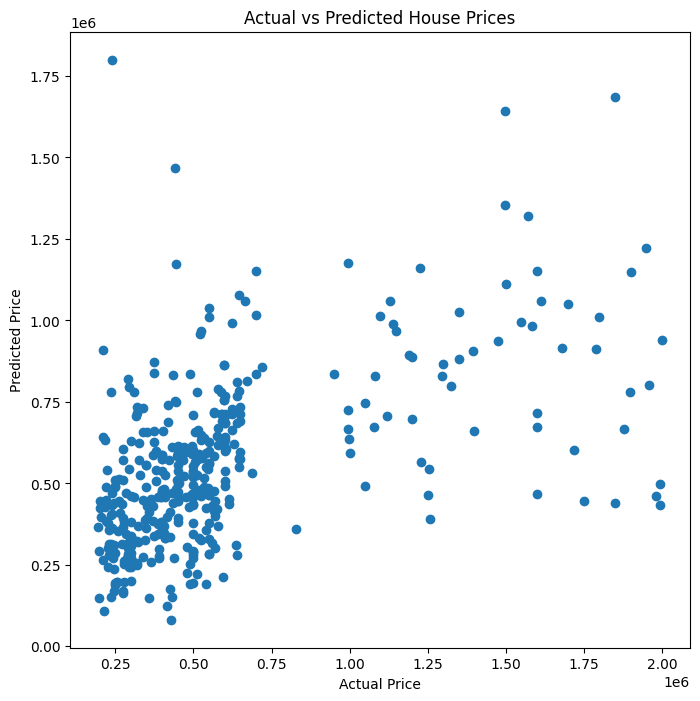

In [44]:
plt.figure(figsize=(8,8))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

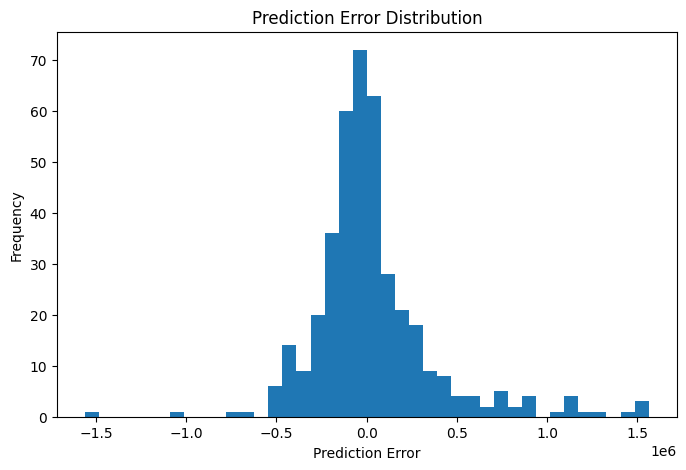

In [45]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=40)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.show()

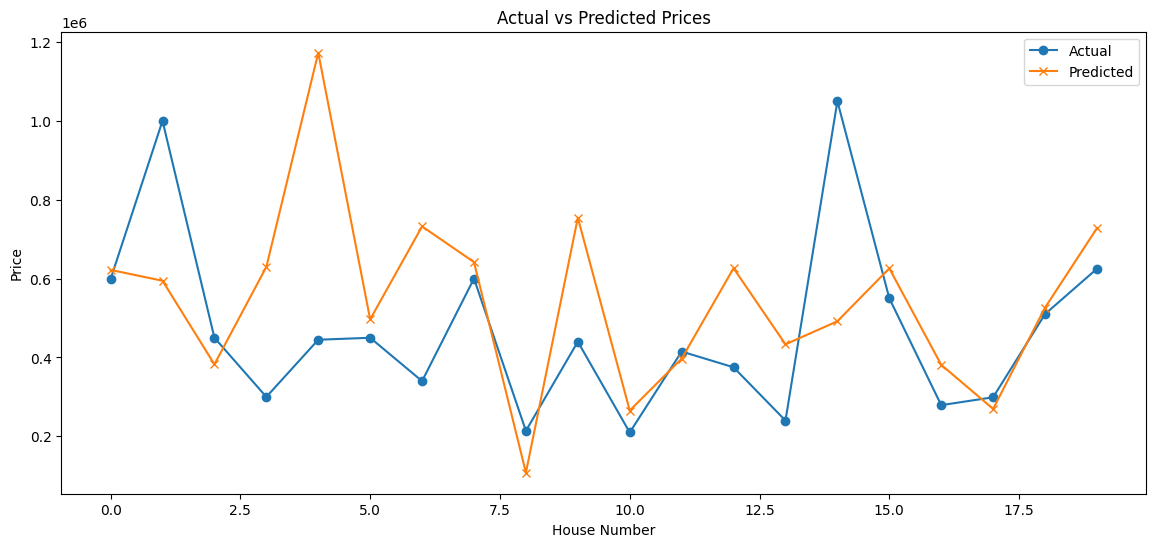

In [46]:
plt.figure(figsize=(14,6))

plt.plot(y_test[:20], label="Actual", marker='o')

plt.plot(y_pred[:20], label="Predicted", marker='x')

plt.xlabel("House Number")

plt.ylabel("Price")

plt.title("Actual vs Predicted Prices")

plt.legend()

plt.show()

In [47]:
results = pd.DataFrame({

    "Actual": y_test,
    "Predicted": y_pred

})

results.to_csv("Predictions.csv", index=False)

print("Prediction File Saved Successfully!")

Prediction File Saved Successfully!


In [48]:
from google.colab import files

files.download("Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
files.download("HousePricePredictionModel.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
new_house = np.array([[4,3,2500,2]])

new_house = scaler.transform(new_house)

image_feature = np.zeros((1,2048))

new_data = np.concatenate(

    [image_feature,new_house],

    axis=1

)

new_data = feature_scaler.transform(new_data)

prediction = model.predict(new_data)

print("Predicted House Price : $", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted House Price : $ 765334.4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [51]:
print("="*50)

print("House Price Prediction Project Completed Successfully")

print("="*50)

print("MAE :", mae)

print("RMSE :", rmse)

print("R² Score :", r2)

print("="*50)

House Price Prediction Project Completed Successfully
MAE : 218329.515625
RMSE : 343387.072185311
R² Score : 0.26863765716552734
